# 14a — India District Agricultural Analysis: EDA & Preprocessing

**Dataset**: 164,673 records | 403 districts | 22 states | 122 crops | 1997-2014

This notebook performs comprehensive exploratory data analysis and preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

PROCESSED = '../data/processed'
OUTPUT = '../outputs/plots'

india = pd.read_csv(f'{PROCESSED}/india_district.csv')
print(f"Dataset Shape: {india.shape}")
print(f"\nColumns: {india.columns.tolist()}")
print(f"\nMissing Values:\n{india.isnull().sum()}")
india.head()

Dataset Shape: (164673, 8)

Columns: ['state', 'district', 'year', 'season', 'crop', 'production', 'annual_rainfall', 'monsoon_rainfall']

Missing Values:
state               0
district            0
year                0
season              0
crop                0
production          0
annual_rainfall     0
monsoon_rainfall    0
dtype: int64


,state,district,year,season,crop,production,annual_rainfall,monsoon_rainfall
0,Andhra Pradesh,Anantapur,1997,Kharif,Arhar/Tur,2600.0,572.7,322.8
1,Andhra Pradesh,Anantapur,1997,Kharif,Bajra,500.0,572.7,322.8
2,Andhra Pradesh,Anantapur,1997,Kharif,Castor seed,100.0,572.7,322.8
3,Andhra Pradesh,Anantapur,1997,Kharif,Cotton(lint),9400.0,572.7,322.8
4,Andhra Pradesh,Anantapur,1997,Kharif,Dry chillies,7100.0,572.7,322.8


## 1. Production Distribution Analysis

Analyzing production distribution with log-scale to handle outliers (e.g., Coconut in TN = 1.25B units).

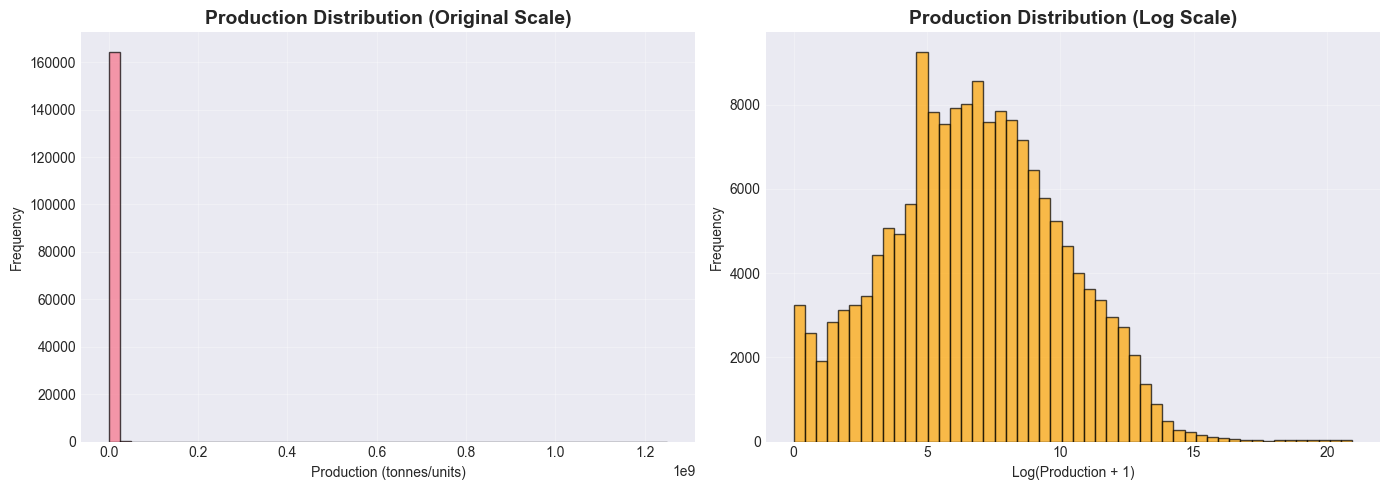

Production Statistics:
count    1.646730e+05
mean     6.405830e+05
std      1.819187e+07
min      0.000000e+00
25%      1.000000e+02
50%      8.740000e+02
75%      8.359000e+03
max      1.250800e+09
Name: production, dtype: float64

Top 5 Production Records:
             state    district      crop    production  year
122207  Tamil Nadu  Coimbatore  Coconut   1.250800e+09  2011
122265  Tamil Nadu  Coimbatore  Coconut   1.212000e+09  2013
64846       Kerala  Malappuram  Coconut   1.125000e+09  2012
64804       Kerala  Malappuram  Coconut   1.063000e+09  2009
64341       Kerala   Kozhikode  Coconut   1.059000e+09  1999


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
axes[0].hist(india['production'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Production Distribution (Original Scale)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Production (tonnes/units)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Log-scale distribution
india['log_production'] = np.log1p(india['production'])
axes[1].hist(india['log_production'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Production Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Production + 1)')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_production_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Production Statistics:")
print(india['production'].describe())
print(f"\nTop 5 Production Records:")
print(india.nlargest(5, 'production')[['state', 'district', 'crop', 'production', 'year']])

**Interpretation**: Production data is heavily right-skewed with extreme outliers (coconut production in coastal states). Log transformation normalizes the distribution for better modeling. The top production records are dominated by coconut (measured in units, not tonnes), which explains the billion-scale values.

## 2. State-wise Crop Diversity

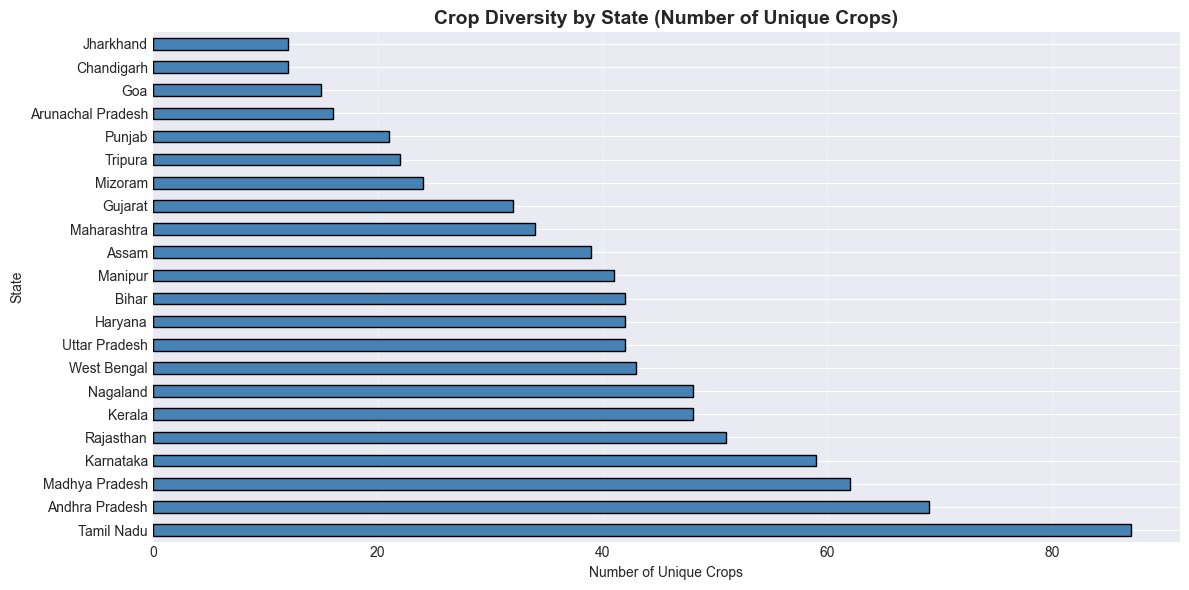

Crop Diversity Summary:
state
Tamil Nadu           87
Andhra Pradesh       69
Madhya Pradesh       62
Karnataka            59
Rajasthan            51
Kerala               48
Nagaland             48
West Bengal          43
Uttar Pradesh        42
Haryana              42
Bihar                42
Manipur              41
Assam                39
Maharashtra          34
Gujarat              32
Mizoram              24
Tripura              22
Punjab               21
Arunachal Pradesh    16
Goa                  15
Chandigarh           12
Jharkhand            12
Name: crop, dtype: int64


In [3]:
crop_diversity = india.groupby('state')['crop'].nunique().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
crop_diversity.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Crop Diversity by State (Number of Unique Crops)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Unique Crops')
plt.ylabel('State')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_crop_diversity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Crop Diversity Summary:")
print(crop_diversity)

**Interpretation**: States like Andhra Pradesh, Karnataka, and Maharashtra show highest crop diversity (80+ crops), indicating diversified agriculture. States with lower diversity may be more vulnerable to crop-specific failures and climate shocks.

## 3. Season-wise Production Analysis

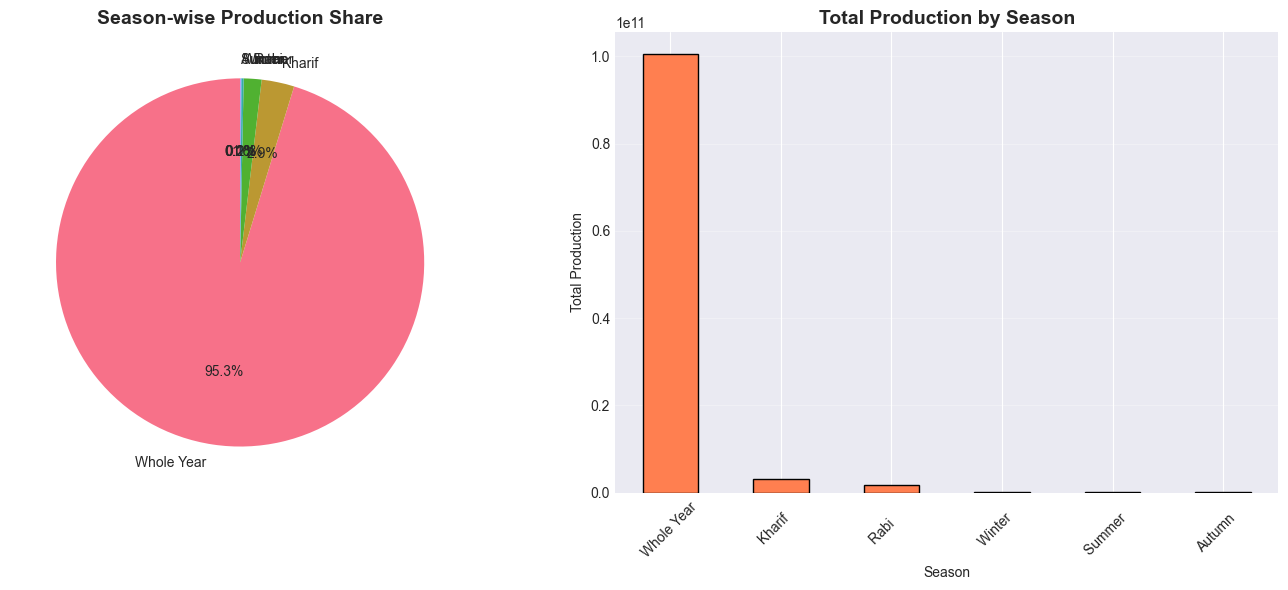

Season-wise Production:
season
Whole Year     1.004882e+11
Kharif         3.026081e+09
Rabi           1.647357e+09
Winter         2.003825e+08
Summer         8.846589e+07
Autumn         3.623972e+07
Name: production, dtype: float64


In [4]:
season_prod = india.groupby('season')['production'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(season_prod, labels=season_prod.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Season-wise Production Share', fontsize=14, fontweight='bold')

# Bar chart
season_prod.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Total Production by Season', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Total Production')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_season_production.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Season-wise Production:")
print(season_prod)

**Interpretation**: Whole Year crops (sugarcane, coconut, perennials) dominate total production. Kharif (monsoon) season shows higher production than Rabi (winter), highlighting monsoon dependency of Indian agriculture.

## 4. Rainfall Distribution Analysis

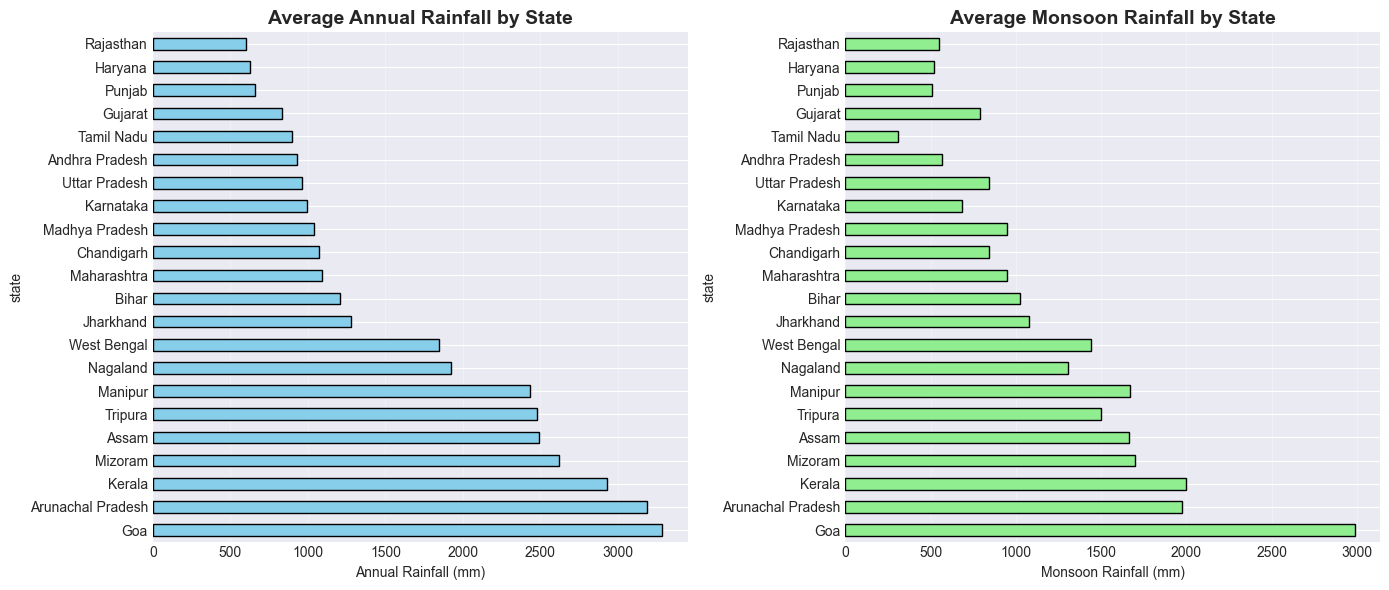

Rainfall Statistics by State:
                   annual_rainfall  monsoon_rainfall
state                                               
Goa                    3284.064423       2985.919231
Arunachal Pradesh      3185.722364       1975.033740
Kerala                 2927.661353       1999.437306
Mizoram                2621.664995       1698.318809
Assam                  2491.519666       1664.245676
Tripura                2479.592570       1497.423399
Manipur                2430.354933       1668.844357
Nagaland               1926.070311       1303.369855
West Bengal            1843.322508       1443.146595
Jharkhand              1278.613985       1075.940230
Bihar                  1206.100594       1024.532895
Maharashtra            1089.484718        946.388182
Chandigarh             1070.600000        844.200000
Madhya Pradesh         1039.720832        945.476358
Karnataka               996.518723        686.764066
Uttar Pradesh           959.772774        842.436223
Andhra Pradesh  

In [5]:
rainfall_by_state = india.groupby('state')[['annual_rainfall', 'monsoon_rainfall']].mean().sort_values('annual_rainfall', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Annual rainfall
rainfall_by_state['annual_rainfall'].plot(kind='barh', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Average Annual Rainfall by State', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Annual Rainfall (mm)')
axes[0].grid(axis='x', alpha=0.3)

# Monsoon rainfall
rainfall_by_state['monsoon_rainfall'].plot(kind='barh', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Average Monsoon Rainfall by State', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Monsoon Rainfall (mm)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_rainfall_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Rainfall Statistics by State:")
print(rainfall_by_state)

**Interpretation**: Coastal states (Kerala, West Bengal) receive highest rainfall (>1000mm), while interior states show lower rainfall. Monsoon contributes 60-70% of annual rainfall, emphasizing monsoon's critical role in Indian agriculture.

## 5. Production-Rainfall Correlation

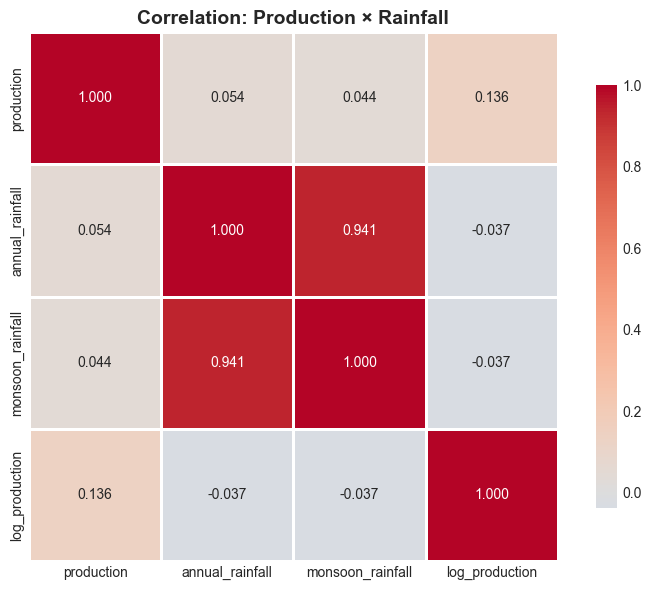

Correlation Matrix:
                  production  annual_rainfall  monsoon_rainfall  \
production          1.000000         0.053517          0.043684   
annual_rainfall     0.053517         1.000000          0.941192   
monsoon_rainfall    0.043684         0.941192          1.000000   
log_production      0.136454        -0.036773         -0.037281   

                  log_production  
production              0.136454  
annual_rainfall        -0.036773  
monsoon_rainfall       -0.037281  
log_production          1.000000  


In [6]:
corr_data = india[['production', 'annual_rainfall', 'monsoon_rainfall', 'log_production']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation: Production × Rainfall', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_production_rainfall_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Correlation Matrix:")
print(corr_data)

**Interpretation**: Weak positive correlation between production and rainfall suggests that while rainfall is important, other factors (irrigation, soil quality, technology) also significantly influence production. Log-transformed production shows similar correlation patterns.

## 6. Top 10 Crops by Production

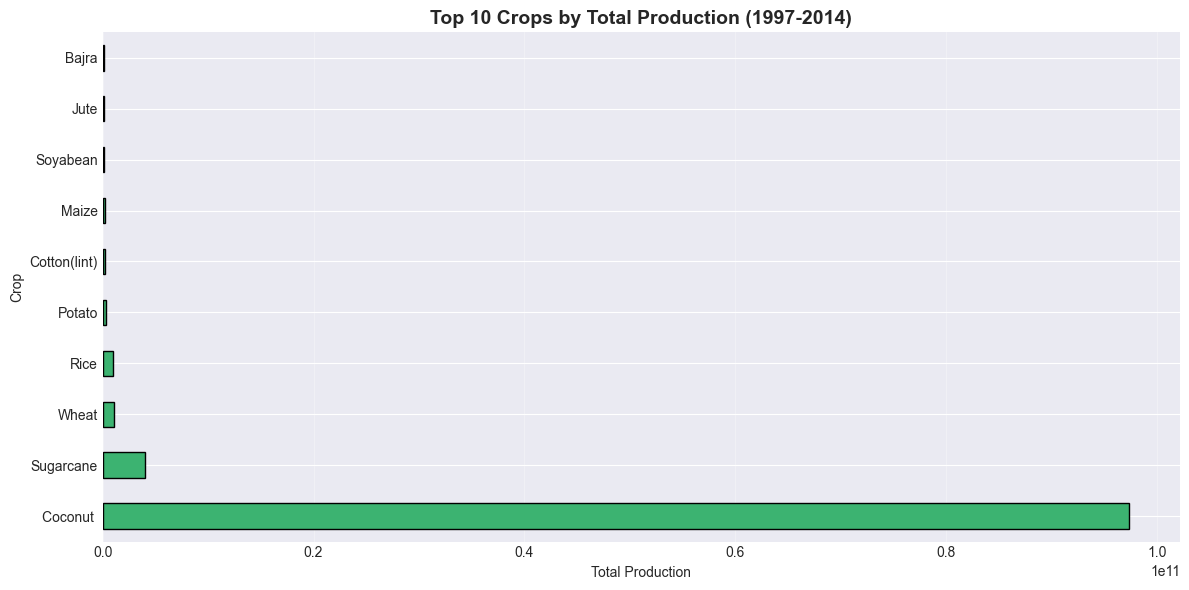

Top 10 Crops:
crop
Coconut         9.731553e+10
Sugarcane       4.024508e+09
Wheat           1.121584e+09
Rice            9.911916e+08
Potato          2.906085e+08
Cotton(lint)    2.306132e+08
Maize           1.852525e+08
Soyabean        1.362635e+08
Jute            1.164000e+08
Bajra           1.102296e+08
Name: production, dtype: float64


In [7]:
top_crops = india.groupby('crop')['production'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_crops.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Top 10 Crops by Total Production (1997-2014)', fontsize=14, fontweight='bold')
plt.xlabel('Total Production')
plt.ylabel('Crop')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_top10_crops.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Top 10 Crops:")
print(top_crops)

**Interpretation**: Coconut dominates due to unit-based measurement (nuts vs tonnes). Rice and sugarcane are the major food/cash crops. This distribution reflects India's agricultural priorities: food security (rice, wheat) and cash crops (sugarcane, cotton).

## 7. Data Preprocessing Summary

In [8]:
# Create processed features
india['year_normalized'] = (india['year'] - india['year'].min()) / (india['year'].max() - india['year'].min())
india['rainfall_ratio'] = india['monsoon_rainfall'] / india['annual_rainfall']

# Save processed data
india.to_csv(f'{PROCESSED}/india_district_processed.csv', index=False)

print("✅ Preprocessing Complete!")
print(f"\nNew Features Created:")
print("- log_production: Log-transformed production")
print("- year_normalized: Normalized year (0-1)")
print("- rainfall_ratio: Monsoon/Annual rainfall ratio")
print(f"\nProcessed data saved to: {PROCESSED}/india_district_processed.csv")
print(f"\nFinal Dataset Shape: {india.shape}")

✅ Preprocessing Complete!

New Features Created:
- log_production: Log-transformed production
- year_normalized: Normalized year (0-1)
- rainfall_ratio: Monsoon/Annual rainfall ratio

Processed data saved to: ../data/processed/india_district_processed.csv

Final Dataset Shape: (164673, 11)
